In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load Dataset and print head of the dataset
df = pd.read_csv("/content/drive/MyDrive/SLIIT/AI_ML/Project/rfe_pca_df.csv")

# 2. Separate features (X) and target (y)
X = df.drop("Depression", axis=1)
y = df["Depression"]

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Initialize and train logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 5. Predictions
y_pred = model.predict(X_test)

# 6. Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8462780269058297

Confusion Matrix:
 [[1828  483]
 [ 374 2890]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.79      0.81      2311
           1       0.86      0.89      0.87      3264

    accuracy                           0.85      5575
   macro avg       0.84      0.84      0.84      5575
weighted avg       0.85      0.85      0.85      5575



In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load Dataset and print head of the dataset
df = pd.read_csv("/content/drive/MyDrive/SLIIT/AI_ML/Project/chi2_pca_df.csv")

# 2. Separate features (X) and target (y)
X = df.drop("Depression", axis=1)
y = df["Depression"]

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Initialize and train logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 5. Predictions
y_pred = model.predict(X_test)

# 6. Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8459192825112107

Confusion Matrix:
 [[1829  482]
 [ 377 2887]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.79      0.81      2311
           1       0.86      0.88      0.87      3264

    accuracy                           0.85      5575
   macro avg       0.84      0.84      0.84      5575
weighted avg       0.85      0.85      0.85      5575



In [5]:
# ----- imports -----
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, precision_recall_curve, auc, classification_report
)
from sklearn.calibration import calibration_curve

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ----- config your file/columns here -----
df = pd.read_csv("/content/drive/MyDrive/SLIIT/AI_ML/Project/rfe_pca_df.csv")   # <- change this to your file path
TARGET   = "Depression"     # <- change if your target is different (e.g., "Is_Depression")

# ----- load -----
df = pd.read_csv("/content/drive/MyDrive/SLIIT/AI_ML/Project/rfe_pca_df.csv")

# basic checks
assert TARGET in df.columns, f"Target column '{TARGET}' not found. Available: {df.columns.tolist()}"
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

print("Shape:", df.shape)
print("Class balance:", y.value_counts(normalize=True).round(3))

# train/val/test split (60/20/20) to leave truly unseen test data for the end
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=RANDOM_STATE
)  # 0.25 of 0.8 = 0.2 -> 60/20/20

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Shape: (27875, 9)
Class balance: Depression
1    0.586
0    0.414
Name: proportion, dtype: float64
Train: (16725, 8) Val: (5575, 8) Test: (5575, 8)


[VAL (Baseline)] Acc=0.847  Prec=0.857  Rec=0.887  F1=0.872  ROC-AUC=0.921

Confusion matrix (VAL):
 [[1828  483]
 [ 368 2896]]


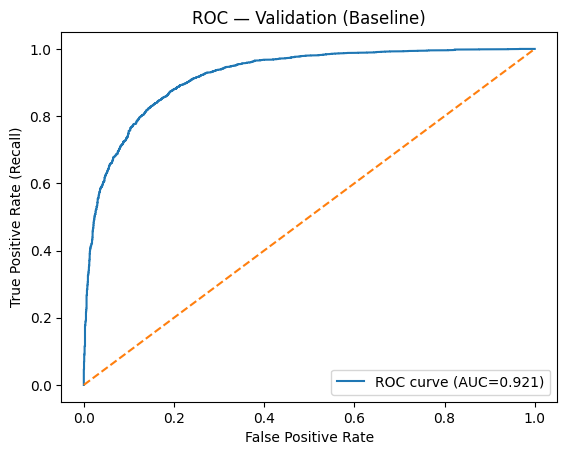

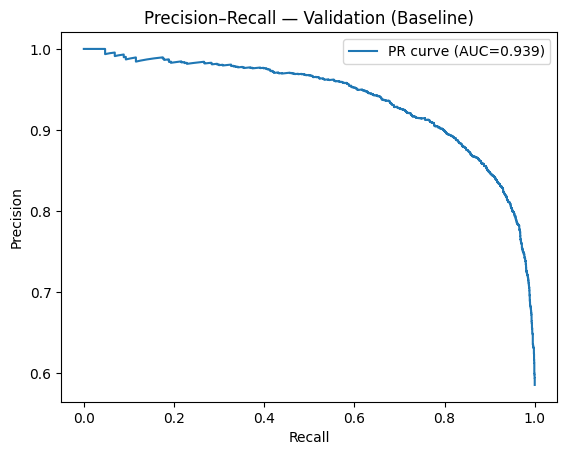

In [6]:
# Pipeline: scale -> logistic regression (baseline)
baseline_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        max_iter=2000,
        random_state=RANDOM_STATE
    ))
])

baseline_clf.fit(X_train, y_train)

# Validation predictions
val_pred = baseline_clf.predict(X_val)
val_proba = baseline_clf.predict_proba(X_val)[:, 1]

# Metrics
def print_metrics(y_true, y_pred, y_proba, split_name="VAL"):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc = roc_auc_score(y_true, y_proba)
    print(f"[{split_name}] Acc={acc:.3f}  Prec={prec:.3f}  Rec={rec:.3f}  F1={f1:.3f}  ROC-AUC={roc:.3f}")

print_metrics(y_val, val_pred, val_proba, "VAL (Baseline)")

# Confusion matrix
cm = confusion_matrix(y_val, val_pred)
print("\nConfusion matrix (VAL):\n", cm)

# ROC curve
fpr, tpr, _ = roc_curve(y_val, val_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC={roc_auc:.3f})")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC — Validation (Baseline)")
plt.legend()
plt.show()

# Precision-Recall curve
prec, rec, _ = precision_recall_curve(y_val, val_proba)
pr_auc = auc(rec, prec)
plt.figure()
plt.plot(rec, prec, label=f"PR curve (AUC={pr_auc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall — Validation (Baseline)")
plt.legend()
plt.show()

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = cross_validate(
    baseline_clf, X_train, y_train,
    cv=cv,
    scoring=["accuracy", "f1", "roc_auc", "precision", "recall"],
    n_jobs=-1, return_train_score=False
)

print("CV mean scores on TRAIN:")
for k, v in cv_results.items():
    if k.startswith("test_"):
        print(f"  {k[5:]}: {np.mean(v):.3f} ± {np.std(v):.3f}")

CV mean scores on TRAIN:
  accuracy: 0.842 ± 0.006
  f1: 0.868 ± 0.005
  roc_auc: 0.917 ± 0.003
  precision: 0.852 ± 0.007
  recall: 0.884 ± 0.007


In [8]:
# ----- Step 4 (fixed) — Hyperparameter search -----
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

search_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        solver="saga",          # supports l1, l2, elasticnet
        max_iter=5000,
        random_state=RANDOM_STATE
    ))
])

# Use a list of dicts; keep only valid params for each penalty
param_grid = [
    {
        "logreg__penalty": ["l2"],
        "logreg__C": [0.01, 0.1, 1.0, 3.0, 10.0],
        "logreg__class_weight": [None, "balanced"],
        # no l1_ratio key here
    },
    {
        "logreg__penalty": ["l1"],
        "logreg__C": [0.01, 0.1, 1.0, 3.0, 10.0],
        "logreg__class_weight": [None, "balanced"],
        # no l1_ratio key here either
    },
    {
        "logreg__penalty": ["elasticnet"],
        "logreg__C": [0.01, 0.1, 1.0, 3.0, 10.0],
        "logreg__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],  # only for elasticnet
        "logreg__class_weight": [None, "balanced"],
    },
]

grid = GridSearchCV(
    estimator=search_pipe,
    param_grid=param_grid,
    scoring="roc_auc",   # prioritize ranking ability
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)
print("Best ROC-AUC (CV):", grid.best_score_)
print("Best params:", grid.best_params_)

best_clf = grid.best_estimator_

# Validate on hold-out VAL
val_pred = best_clf.predict(X_val)
val_proba = best_clf.predict_proba(X_val)[:, 1]
print_metrics(y_val, val_pred, val_proba, "VAL (Tuned)")
print("\nReport (VAL):\n", classification_report(y_val, val_pred))

Fitting 5 folds for each of 70 candidates, totalling 350 fits
Best ROC-AUC (CV): 0.917399464533991
Best params: {'logreg__C': 1.0, 'logreg__class_weight': 'balanced', 'logreg__l1_ratio': 0.7, 'logreg__penalty': 'elasticnet'}
[VAL (Tuned)] Acc=0.841  Prec=0.877  Rec=0.847  F1=0.862  ROC-AUC=0.921

Report (VAL):
               precision    recall  f1-score   support

           0       0.79      0.83      0.81      2311
           1       0.88      0.85      0.86      3264

    accuracy                           0.84      5575
   macro avg       0.84      0.84      0.84      5575
weighted avg       0.84      0.84      0.84      5575



Best threshold by F1: 0.30  |  F1=0.875  Prec=0.827  Rec=0.930


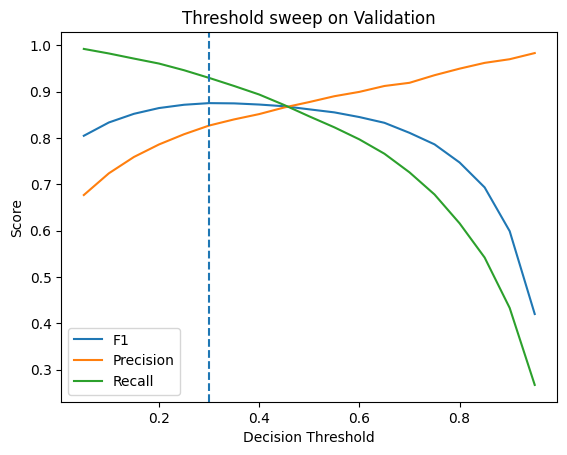

In [9]:
thresholds = np.linspace(0.05, 0.95, 19)
f1s, recalls, precisions = [], [], []
for t in thresholds:
    preds_t = (val_proba >= t).astype(int)
    f1s.append(f1_score(y_val, preds_t))
    recalls.append(recall_score(y_val, preds_t))
    precisions.append(precision_score(y_val, preds_t, zero_division=0))

best_idx = int(np.argmax(f1s))
best_th = float(thresholds[best_idx])
print(f"Best threshold by F1: {best_th:.2f}  |  F1={f1s[best_idx]:.3f}  Prec={precisions[best_idx]:.3f}  Rec={recalls[best_idx]:.3f}")

plt.figure()
plt.plot(thresholds, f1s, label="F1")
plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.axvline(best_th, linestyle="--")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Threshold sweep on Validation")
plt.legend()
plt.show()

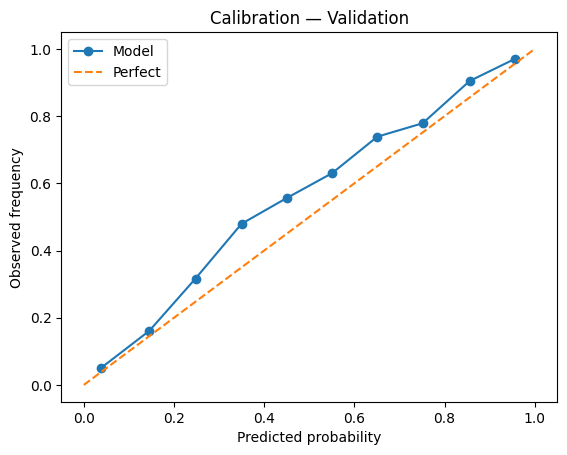

In [10]:
prob_true, prob_pred = calibration_curve(y_val, val_proba, n_bins=10, strategy="uniform")
plt.figure()
plt.plot(prob_pred, prob_true, marker="o", label="Model")
plt.plot([0,1],[0,1], linestyle="--", label="Perfect")
plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.title("Calibration — Validation")
plt.legend()
plt.show()

# If under/over-confident, consider:
# from sklearn.calibration import CalibratedClassifierCV
# calibrated = CalibratedClassifierCV(best_clf, cv=cv, method="isotonic")
# calibrated.fit(X_train, y_train)
# val_proba_cal = calibrated.predict_proba(X_val)[:,1]

[TEST (0.5 threshold)] Acc=0.844  Prec=0.879  Rec=0.851  F1=0.865  ROC-AUC=0.920

Report (TEST, 0.5):
               precision    recall  f1-score   support

           0       0.80      0.83      0.82      2311
           1       0.88      0.85      0.87      3264

    accuracy                           0.84      5575
   macro avg       0.84      0.84      0.84      5575
weighted avg       0.85      0.84      0.84      5575

[TEST (t=0.30)] Acc=0.838  Prec=0.822  Rec=0.923  F1=0.870  ROC-AUC=0.920

Report (TEST, tuned):
               precision    recall  f1-score   support

           0       0.87      0.72      0.79      2311
           1       0.82      0.92      0.87      3264

    accuracy                           0.84      5575
   macro avg       0.85      0.82      0.83      5575
weighted avg       0.84      0.84      0.83      5575



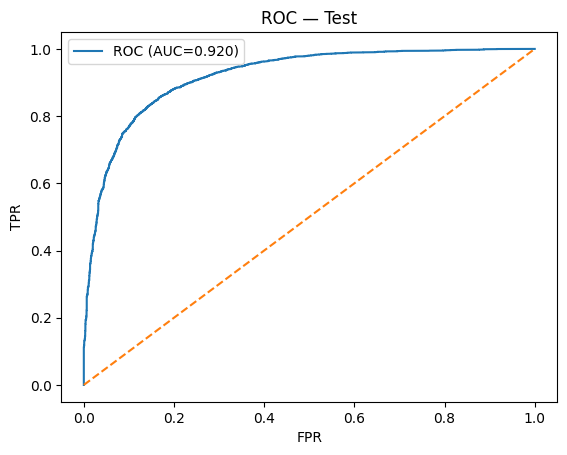

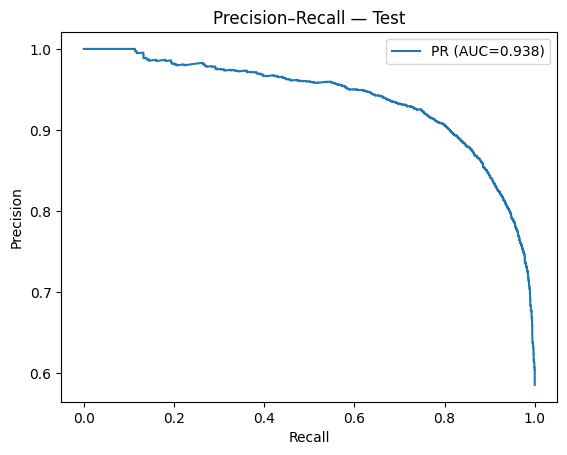

In [11]:
# Use tuned model 'best_clf' and chosen threshold 'best_th'
test_proba = best_clf.predict_proba(X_test)[:, 1]
test_pred_default = (test_proba >= 0.5).astype(int)
test_pred_tuned   = (test_proba >= best_th).astype(int)

print_metrics(y_test, test_pred_default, test_proba, "TEST (0.5 threshold)")
print("\nReport (TEST, 0.5):\n", classification_report(y_test, test_pred_default))

print_metrics(y_test, test_pred_tuned, test_proba, f"TEST (t={best_th:.2f})")
print("\nReport (TEST, tuned):\n", classification_report(y_test, test_pred_tuned))

# Final ROC/PR on TEST
fpr, tpr, _ = roc_curve(y_test, test_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC (AUC={roc_auc:.3f})")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC — Test")
plt.legend()
plt.show()

prec, rec, _ = precision_recall_curve(y_test, test_proba)
pr_auc = auc(rec, prec)
plt.figure()
plt.plot(rec, prec, label=f"PR (AUC={pr_auc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall — Test")
plt.legend()
plt.show()

=== THRESHOLD SELECTION ===
Best threshold on VAL by F1: 0.30

=== METRICS ===
[TRAIN @0.50] Acc=0.839  Prec=0.875  Rec=0.846  F1=0.860  ROC-AUC=0.918  PR-AUC=0.936  Brier=0.1139  CM=(np.int64(5753), np.int64(1179), np.int64(1508), np.int64(8285))
[VAL   @0.50] Acc=0.841  Prec=0.877  Rec=0.847  F1=0.862  ROC-AUC=0.921  PR-AUC=0.939  Brier=0.1116  CM=(np.int64(1925), np.int64(386), np.int64(501), np.int64(2763))
[TEST  @0.50] Acc=0.844  Prec=0.879  Rec=0.851  F1=0.865  ROC-AUC=0.920  PR-AUC=0.938  Brier=0.1117  CM=(np.int64(1929), np.int64(382), np.int64(485), np.int64(2779))
[VAL   @0.30] Acc=0.845  Prec=0.827  Rec=0.930  F1=0.875  ROC-AUC=0.921  PR-AUC=0.939  Brier=0.1116  CM=(np.int64(1675), np.int64(636), np.int64(230), np.int64(3034))
[TEST  @0.30] Acc=0.838  Prec=0.822  Rec=0.923  F1=0.870  ROC-AUC=0.920  PR-AUC=0.938  Brier=0.1117  CM=(np.int64(1657), np.int64(654), np.int64(250), np.int64(3014))

Classification report (TEST @0.50):
               precision    recall  f1-score   

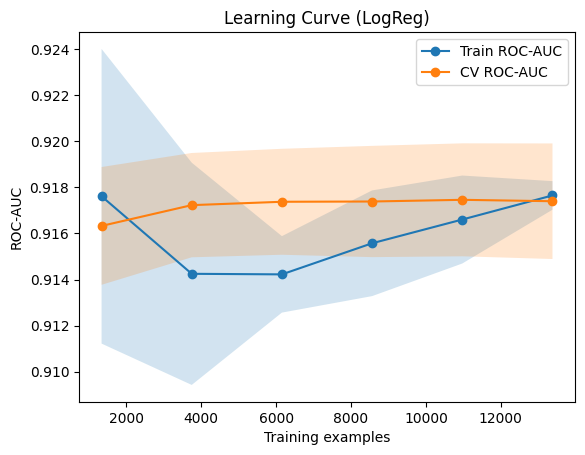

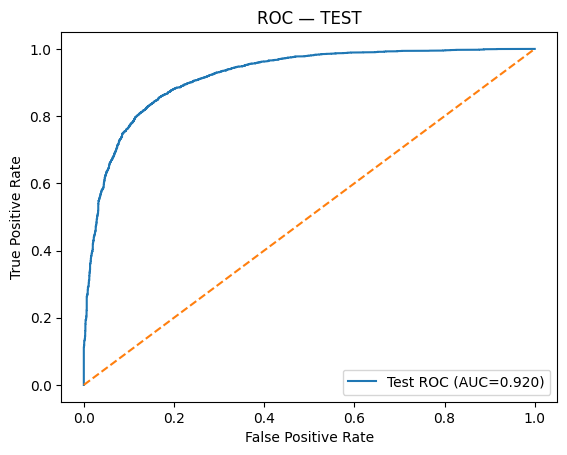

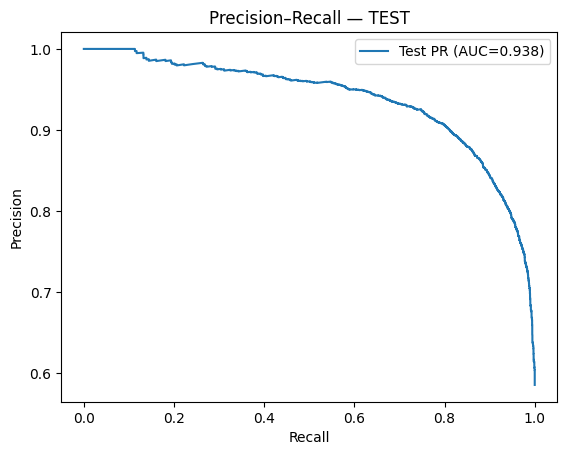

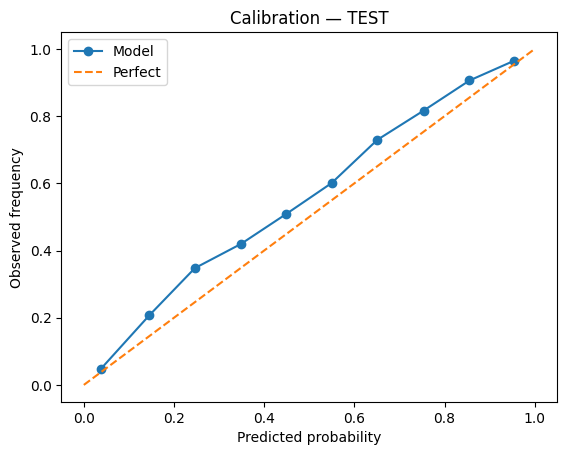

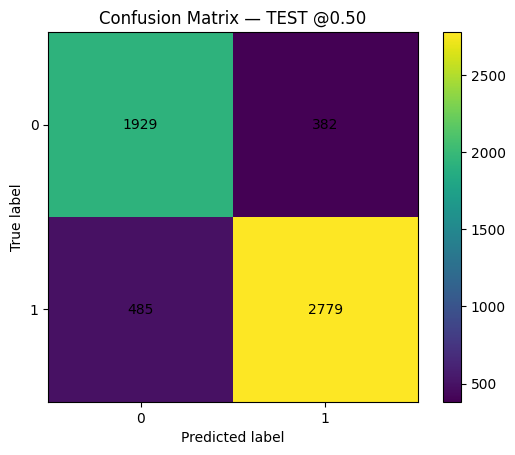

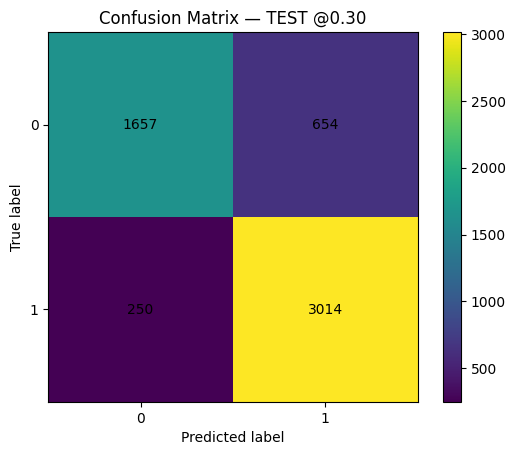

In [12]:
# === Final Model Performance + Visualizations (Logistic Regression) ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, precision_recall_curve, auc, brier_score_loss,
    confusion_matrix, classification_report, roc_curve
)
from sklearn.model_selection import StratifiedKFold, learning_curve, cross_val_score

RANDOM_STATE = 42

# 0) If you don't already have a fitted 'best_clf', we train a reasonable baseline now.
try:
    best_clf
except NameError:
    best_clf = Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            solver="saga", penalty="elasticnet", l1_ratio=0.3,
            C=1.0, class_weight=None, max_iter=5000, random_state=RANDOM_STATE
        ))
    ])
    best_clf.fit(X_train, y_train)

# ---------------- helpers ----------------
def metrics_from_proba(y_true, proba, t=0.5):
    pred = (proba >= t).astype(int)
    acc = accuracy_score(y_true, pred)
    prec = precision_score(y_true, pred, zero_division=0)
    rec = recall_score(y_true, pred, zero_division=0)
    f1 = f1_score(y_true, pred, zero_division=0)
    roc = roc_auc_score(y_true, proba)
    p, r, _ = precision_recall_curve(y_true, proba)
    pr_auc = auc(r, p)
    brier = brier_score_loss(y_true, proba)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    return acc, prec, rec, f1, roc, pr_auc, brier, (tn, fp, fn, tp)

def plot_cm(cm, title):
    fig, ax = plt.subplots()
    im = ax.imshow(cm, interpolation="nearest")
    ax.set_title(title)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, f"{v}", ha="center", va="center")
    plt.colorbar(im)
    plt.show()

# ---------------- 1) Choose decision threshold on VAL (max F1) ----------------
val_proba = best_clf.predict_proba(X_val)[:, 1]
thresholds = np.linspace(0.05, 0.95, 19)
f1s = [f1_score(y_val, (val_proba >= t).astype(int)) for t in thresholds]
best_th = float(thresholds[int(np.argmax(f1s))])

# ---------------- 2) Compute metrics ----------------
train_proba = best_clf.predict_proba(X_train)[:, 1]
test_proba  = best_clf.predict_proba(X_test)[:, 1]

train_metrics = metrics_from_proba(y_train, train_proba, 0.5)
val_metrics_05 = metrics_from_proba(y_val, val_proba, 0.5)
test_metrics_05 = metrics_from_proba(y_test, test_proba, 0.5)
val_metrics_t  = metrics_from_proba(y_val, val_proba, best_th)
test_metrics_t = metrics_from_proba(y_test, test_proba, best_th)

print(f"=== THRESHOLD SELECTION ===\nBest threshold on VAL by F1: {best_th:.2f}\n")

def print_line(tag, m):
    acc, prec, rec, f1, roc, pr, brier, cm = m
    print(f"[{tag}] Acc={acc:.3f}  Prec={prec:.3f}  Rec={rec:.3f}  F1={f1:.3f}  "
          f"ROC-AUC={roc:.3f}  PR-AUC={pr:.3f}  Brier={brier:.4f}  CM={cm}")

print("=== METRICS ===")
print_line("TRAIN @0.50", train_metrics)
print_line("VAL   @0.50", val_metrics_05)
print_line("TEST  @0.50", test_metrics_05)
print_line(f"VAL   @{best_th:.2f}", val_metrics_t)
print_line(f"TEST  @{best_th:.2f}", test_metrics_t)

print("\nClassification report (TEST @0.50):\n", classification_report(y_test, (test_proba >= 0.5).astype(int)))
print(f"\nClassification report (TEST @{best_th:.2f}):\n", classification_report(y_test, (test_proba >= best_th).astype(int)))

# ---------------- 3) Quick generalization diagnosis ----------------
train_roc = train_metrics[4]
val_roc   = val_metrics_05[4]
test_roc  = test_metrics_05[4]

diagnosis = "Good generalization."
if train_roc - val_roc > 0.05:
    diagnosis = "Likely OVERFITTING (train ROC-AUC notably > val/test)."
elif max(train_roc, val_roc, test_roc) < 0.65:
    diagnosis = "Likely UNDERFITTING (all ROC-AUC are low)."

print("\n=== DIAGNOSIS ===")
print(f"Train ROC-AUC={train_roc:.3f}  Val ROC-AUC={val_roc:.3f}  Test ROC-AUC={test_roc:.3f}")
print(diagnosis)

# ---------------- 4) Learning curve (overfit/underfit view) ----------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_clf, X=X_train, y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 6), cv=cv,
    scoring="roc_auc", n_jobs=-1, shuffle=True, random_state=RANDOM_STATE
)
train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
val_mean, val_std     = val_scores.mean(axis=1), val_scores.std(axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, marker="o", label="Train ROC-AUC")
plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.2)
plt.plot(train_sizes, val_mean, marker="o", label="CV ROC-AUC")
plt.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.2)
plt.xlabel("Training examples")
plt.ylabel("ROC-AUC")
plt.title("Learning Curve (LogReg)")
plt.legend()
plt.show()

# ---------------- 5) ROC curve (TEST) ----------------
fpr, tpr, _ = roc_curve(y_test, test_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label=f"Test ROC (AUC={roc_auc:.3f})")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC — TEST")
plt.legend()
plt.show()

# ---------------- 6) Precision–Recall (TEST) ----------------
prec, rec, _ = precision_recall_curve(y_test, test_proba)
pr_auc = auc(rec, prec)
plt.figure()
plt.plot(rec, prec, label=f"Test PR (AUC={pr_auc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall — TEST")
plt.legend()
plt.show()

# ---------------- 7) Calibration curve (TEST) ----------------
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(y_test, test_proba, n_bins=10, strategy="uniform")
plt.figure()
plt.plot(prob_pred, prob_true, marker="o", label="Model")
plt.plot([0,1],[0,1], linestyle="--", label="Perfect")
plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.title("Calibration — TEST")
plt.legend()
plt.show()

# ---------------- 8) Confusion matrices (TEST @0.50 and tuned) ----------------
cm_05 = confusion_matrix(y_test, (test_proba >= 0.5).astype(int))
cm_t  = confusion_matrix(y_test, (test_proba >= best_th).astype(int))
plot_cm(cm_05, "Confusion Matrix — TEST @0.50")
plot_cm(cm_t,  f"Confusion Matrix — TEST @{best_th:.2f}")